# PCA + K-Means Clustering
## Global Air Quality & Deforestation Dataset
**Fuente:** [Kaggle - Global Air Quality and Respiratory Health Outcomes](https://www.kaggle.com/datasets/tfisthis/global-air-quality-and-respiratory-health-outcomes)

**Pipeline:** Preprocesamiento → StandardScaler → PCA → K-Means → Perfilado de clusters

**Seed fijo:** 333

## 1. Importaciones y configuración

In [1]:
# --- Librerías estándar de análisis ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

# --- Preprocesamiento y reducción de dimensionalidad ---
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --- Clustering ---
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

# --- Configuración global ---
SEED = 333
np.random.seed(SEED)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print('Librerías cargadas correctamente ✔')

Librerías cargadas correctamente ✔


## 2. Carga y exploración inicial del dataset

In [2]:
# Cargar dataset
df = pd.read_csv('global_air_quality_deforestation_dataset.csv', na_values='-')

print(f'Shape: {df.shape}')
print(f'Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}')
print()
df.head()

Shape: (35000, 15)
Filas: 35,000 | Columnas: 15



,Country,City,Year,AQI,PM2.5,PM10,Deforestation_Rate_%,Afforestation_Rate_%,Vehicles_Increase_%,Industries_Increase_%,Env_Budget_Million_USD,Population_Density_Per_SqKm,CO2_Emissions_MT,Green_Space_Ratio_%,Avg_Life_Expectancy_Index
0,Argentina,Buenos Aires,2014,144.02,95.38,124.16,3.93,2.32,11.03,5.13,68.30,7612.92,196.42,35.41,75.54
1,Argentina,Buenos Aires,2014,161.81,73.35,123.64,3.54,1.85,4.50,7.30,143.51,10983.91,174.43,31.03,74.50
2,Argentina,Buenos Aires,2014,133.11,55.49,128.95,1.94,0.39,11.50,8.29,246.25,3442.93,214.09,35.80,76.62
3,Argentina,Buenos Aires,2014,153.11,82.18,122.18,3.94,2.30,12.01,8.87,241.67,1689.14,213.00,41.28,75.28
4,Argentina,Buenos Aires,2014,132.52,77.86,110.86,2.14,1.92,9.94,4.35,278.98,12838.73,182.23,30.79,76.72


In [3]:
# Tipos de datos y valores nulos
print('=== Tipos de datos ===')
print(df.dtypes)
print()
print('=== Valores nulos ===')
print(df.isnull().sum())

=== Tipos de datos ===
Country                         object
City                            object
Year                             int64
AQI                            float64
PM2.5                          float64
PM10                           float64
Deforestation_Rate_%           float64
Afforestation_Rate_%           float64
Vehicles_Increase_%            float64
Industries_Increase_%          float64
Env_Budget_Million_USD         float64
Population_Density_Per_SqKm    float64
CO2_Emissions_MT               float64
Green_Space_Ratio_%            float64
Avg_Life_Expectancy_Index      float64
dtype: object

=== Valores nulos ===
Country                        0
City                           0
Year                           0
AQI                            0
PM2.5                          0
PM10                           0
Deforestation_Rate_%           0
Afforestation_Rate_%           0
Vehicles_Increase_%            0
Industries_Increase_%          0
Env_Budget_Million_USD   

In [4]:
# Estadísticas descriptivas de las variables numéricas
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std'])

,count,mean,std,min,25%,50%,75%,max
Year,35000.000000,2018.498914,2.861409,2014.000000,2016.000000,2018.000000,2021.000000,2023.000000
AQI,35000.000000,133.165543,86.385255,15.000000,66.607500,122.235000,179.392500,438.200000
PM2.5,35000.000000,73.190470,49.488236,6.000000,35.647500,65.500000,100.002500,268.370000
PM10,35000.000000,119.846406,79.927673,10.500000,58.892500,107.970000,163.590000,443.020000
Deforestation_Rate_%,35000.000000,2.402560,1.635043,0.050000,0.920000,2.240000,3.670000,7.000000
Afforestation_Rate_%,35000.000000,1.780373,1.190500,0.100000,0.820000,1.480000,2.540000,5.000000
Vehicles_Increase_%,35000.000000,9.248048,5.683271,1.000000,4.920000,7.770000,12.500000,25.000000
Industries_Increase_%,35000.000000,6.468521,4.014841,0.500000,3.500000,5.600000,8.750000,18.000000
Env_Budget_Million_USD,35000.000000,326.663760,299.353821,10.000000,109.520000,222.220000,390.345000,1199.980000
Population_Density_Per_SqKm,35000.000000,9216.702391,6568.983425,200.730000,4073.935000,8175.560000,12091.130000,29998.320000


## 3. Selección de variables para PCA

Se excluyen las variables categóricas (`Country`, `City`) y la variable temporal (`Year`), que no aportan información continua para la reducción de dimensionalidad.

In [5]:
# Variables numéricas continuas para PCA
FEATURES = [
    'AQI',
    'PM2.5',
    'PM10',
    'Deforestation_Rate_%',
    'Afforestation_Rate_%',
    'Vehicles_Increase_%',
    'Industries_Increase_%',
    'Env_Budget_Million_USD',
    'Population_Density_Per_SqKm',
    'CO2_Emissions_MT',
    'Green_Space_Ratio_%',
    'Avg_Life_Expectancy_Index'
]

X = df[FEATURES].copy()
print(f'Variables seleccionadas: {len(FEATURES)}')
print(FEATURES)

Variables seleccionadas: 12
['AQI', 'PM2.5', 'PM10', 'Deforestation_Rate_%', 'Afforestation_Rate_%', 'Vehicles_Increase_%', 'Industries_Increase_%', 'Env_Budget_Million_USD', 'Population_Density_Per_SqKm', 'CO2_Emissions_MT', 'Green_Space_Ratio_%', 'Avg_Life_Expectancy_Index']


## 4. Análisis de correlación

Antes de PCA, inspeccionamos la matriz de correlación para verificar que existen correlaciones entre variables (condición necesaria para que PCA sea útil).

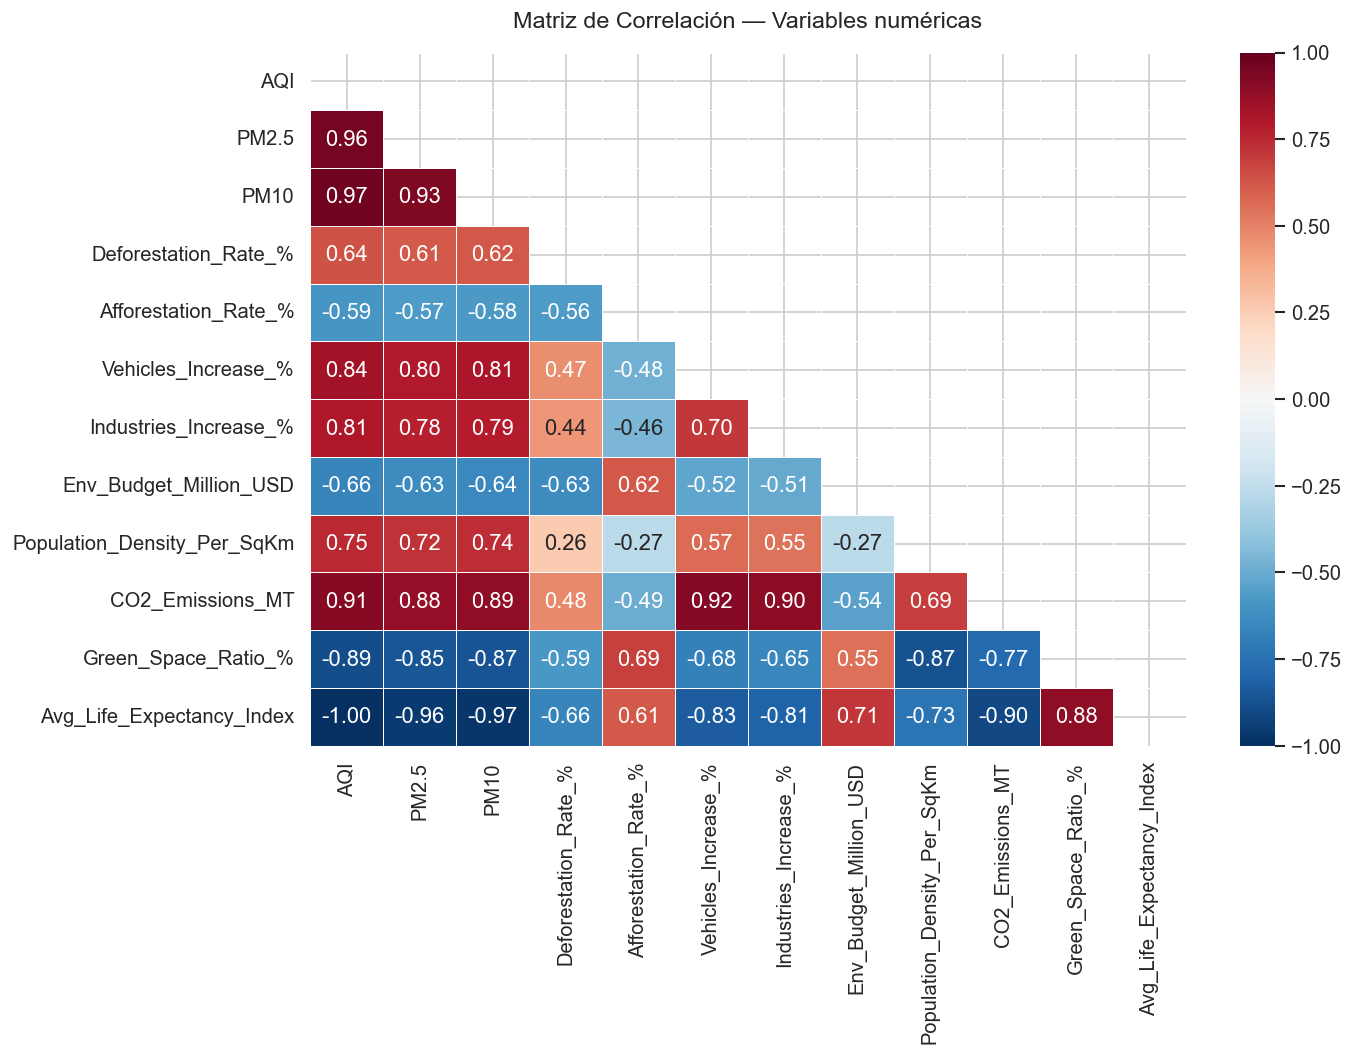

In [6]:
fig, ax = plt.subplots(figsize=(12, 9))

corr_matrix = X.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Solo triángulo inferior

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax
)

ax.set_title('Matriz de Correlación — Variables numéricas', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

## 5. Estandarización

PCA es sensible a la escala. Se aplica `StandardScaler` (media=0, desviación estándar=1) para que ninguna variable domine por unidad de medida.

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Verificar estandarización
print('Media por variable (≈ 0):')
print(np.round(X_scaled.mean(axis=0), 4))
print()
print('Desviación estándar por variable (≈ 1):')
print(np.round(X_scaled.std(axis=0), 4))

Media por variable (≈ 0):
[-0.  0. -0.  0.  0.  0. -0. -0.  0.  0.  0.  0.]

Desviación estándar por variable (≈ 1):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 6. PCA — Análisis de varianza explicada

Primero ajustamos PCA con todos los componentes para evaluar cuántos retener.

In [8]:
# PCA completo para evaluar varianza
pca_full = PCA(random_state=SEED)
pca_full.fit(X_scaled)

# Varianza explicada individual y acumulada
var_exp = pca_full.explained_variance_ratio_
var_cum = np.cumsum(var_exp)

# Tabla resumen
resumen_pca = pd.DataFrame({
    'Componente': [f'PC{i+1}' for i in range(len(var_exp))],
    'Eigenvalue': pca_full.explained_variance_,
    'Var. Explicada (%)': var_exp * 100,
    'Var. Acumulada (%)': var_cum * 100
})
print(resumen_pca.to_string(index=False))

Componente   Eigenvalue  Var. Explicada (%)  Var. Acumulada (%)
       PC1 8.823434e+00        7.352652e+01           73.526517
       PC2 1.180012e+00        9.833156e+00           83.359673
       PC3 6.559313e-01        5.465938e+00           88.825611
       PC4 4.628107e-01        3.856645e+00           92.682256
       PC5 3.479123e-01        2.899186e+00           95.581442
       PC6 2.953748e-01        2.461387e+00           98.042829
       PC7 1.324800e-01        1.103969e+00           99.146798
       PC8 6.605786e-02        5.504664e-01           99.697264
       PC9 2.508329e-02        2.090214e-01           99.906285
      PC10 1.124530e-02        9.370820e-02           99.999994
      PC11 6.449656e-07        5.374559e-06           99.999999
      PC12 1.173529e-07        9.779129e-07          100.000000


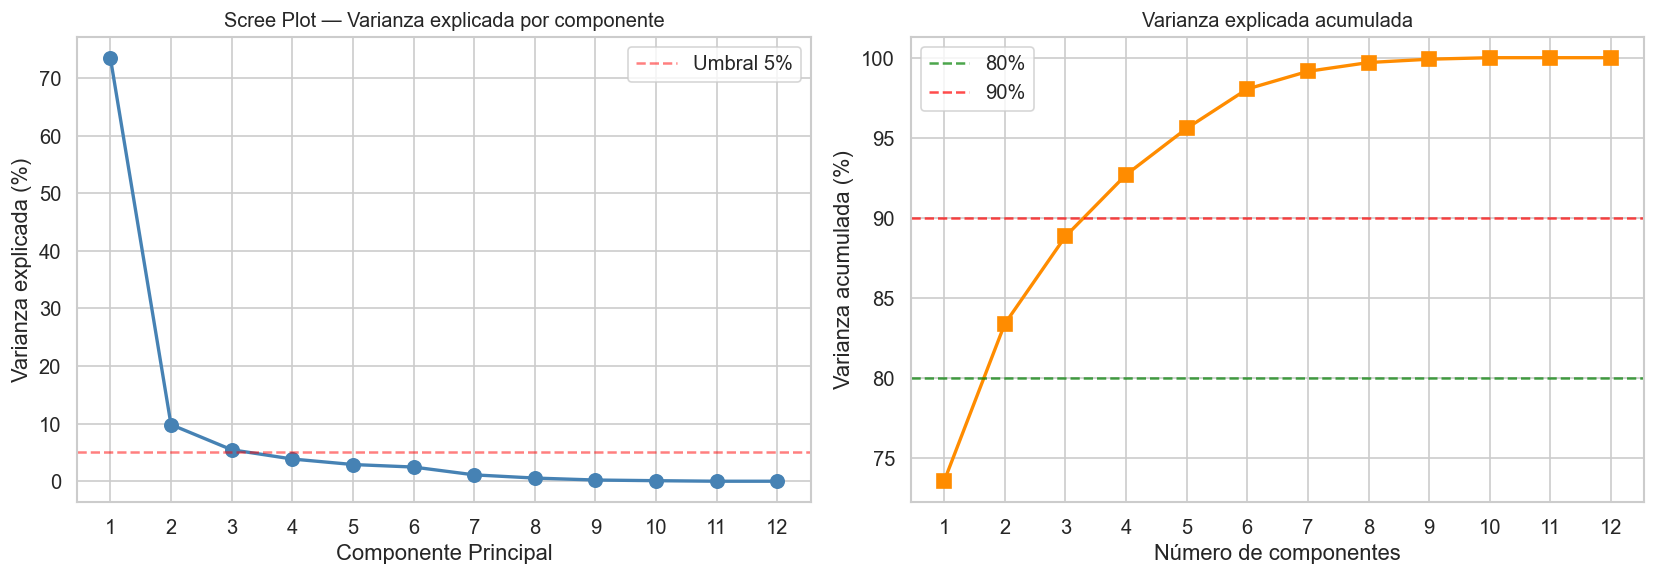

Componentes para explicar ≥80% de varianza: 2
Componentes para explicar ≥90% de varianza: 4


In [9]:
# Scree Plot + Varianza acumulada
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

n_comp = len(var_exp)
x_ticks = range(1, n_comp + 1)

# --- Scree Plot ---
axes[0].plot(x_ticks, var_exp * 100, 'o-', color='steelblue', linewidth=2, markersize=8)
axes[0].set_title('Scree Plot — Varianza explicada por componente', fontsize=12)
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Varianza explicada (%)')
axes[0].set_xticks(x_ticks)
axes[0].axhline(y=5, color='red', linestyle='--', alpha=0.5, label='Umbral 5%')
axes[0].legend()

# --- Varianza acumulada ---
axes[1].plot(x_ticks, var_cum * 100, 's-', color='darkorange', linewidth=2, markersize=8)
axes[1].axhline(y=80, color='green', linestyle='--', alpha=0.7, label='80%')
axes[1].axhline(y=90, color='red', linestyle='--', alpha=0.7, label='90%')
axes[1].set_title('Varianza explicada acumulada', fontsize=12)
axes[1].set_xlabel('Número de componentes')
axes[1].set_ylabel('Varianza acumulada (%)')
axes[1].set_xticks(x_ticks)
axes[1].legend()

plt.tight_layout()
plt.show()

# Cuántos componentes para 80% y 90%
n_80 = np.argmax(var_cum >= 0.80) + 1
n_90 = np.argmax(var_cum >= 0.90) + 1
print(f'Componentes para explicar ≥80% de varianza: {n_80}')
print(f'Componentes para explicar ≥90% de varianza: {n_90}')

## 7. PCA final — Aplicar con n componentes seleccionados

In [10]:
# Seleccionar número de componentes (ajustar según scree plot)
N_COMPONENTS = n_80  # Componentes que explican ≥80% varianza

pca = PCA(n_components=N_COMPONENTS, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

print(f'PCA aplicado con {N_COMPONENTS} componentes')
print(f'Varianza explicada total: {pca.explained_variance_ratio_.sum()*100:.2f}%')
print(f'Shape original: {X_scaled.shape} → Shape reducido: {X_pca.shape}')

PCA aplicado con 2 componentes
Varianza explicada total: 83.36%
Shape original: (35000, 12) → Shape reducido: (35000, 2)


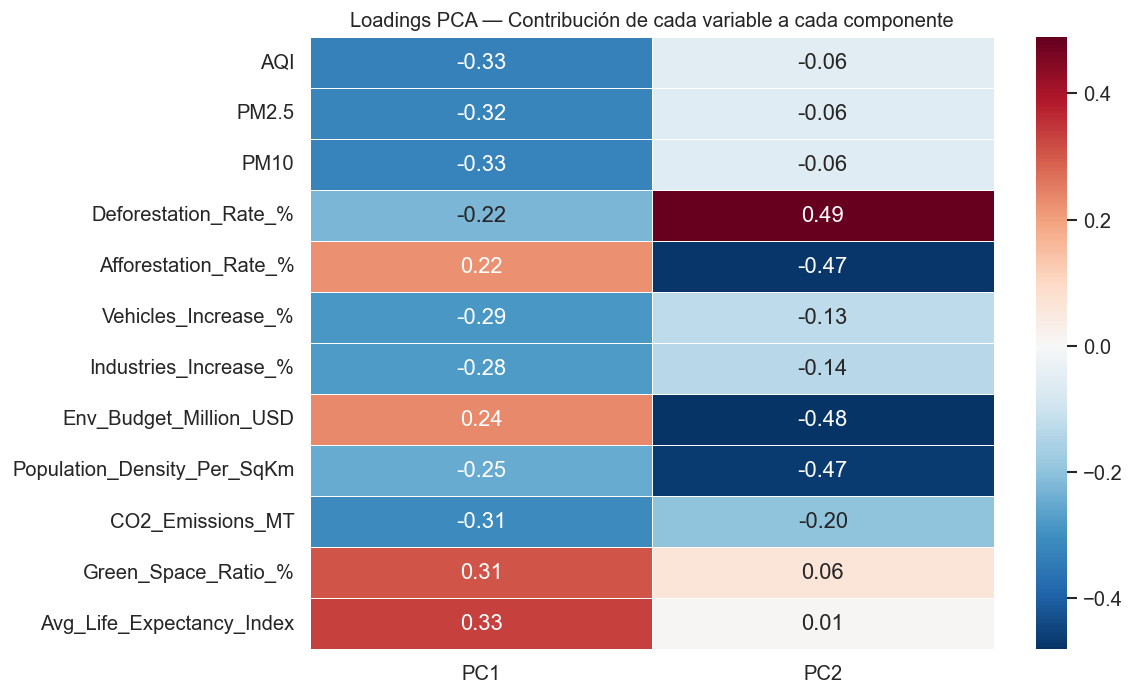


Loadings:
                               PC1    PC2
AQI                         -0.332 -0.056
PM2.5                       -0.322 -0.058
PM10                        -0.325 -0.057
Deforestation_Rate_%        -0.224  0.490
Afforestation_Rate_%         0.223 -0.473
Vehicles_Increase_%         -0.287 -0.127
Industries_Increase_%       -0.279 -0.135
Env_Budget_Million_USD       0.236 -0.481
Population_Density_Per_SqKm -0.249 -0.467
CO2_Emissions_MT            -0.312 -0.198
Green_Space_Ratio_%          0.306  0.063
Avg_Life_Expectancy_Index    0.333  0.005


In [11]:
# Loadings: contribución de cada variable a cada componente
loadings = pd.DataFrame(
    pca.components_.T,
    index=FEATURES,
    columns=[f'PC{i+1}' for i in range(N_COMPONENTS)]
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    loadings,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Loadings PCA — Contribución de cada variable a cada componente', fontsize=12)
plt.tight_layout()
plt.show()

print('\nLoadings:')
print(loadings.round(3))

## 8. K-Means — Determinación del número óptimo de clusters

Se usan dos métodos complementarios:
- **Método del codo (Elbow):** busca el punto donde la inercia deja de disminuir significativamente
- **Silhouette Score:** mide qué tan bien separados están los clusters (más alto = mejor)

In [12]:
# Rango de k a evaluar
K_RANGE = range(2, 11)

inertias = []
silhouettes = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca, labels))
    print(f'k={k} | Inercia: {km.inertia_:,.1f} | Silhouette: {silhouette_score(X_pca, labels):.4f}')

k=2 | Inercia: 145,158.3 | Silhouette: 0.5310
k=3 | Inercia: 62,434.2 | Silhouette: 0.5582
k=4 | Inercia: 45,383.8 | Silhouette: 0.4639
k=5 | Inercia: 35,926.2 | Silhouette: 0.4483
k=6 | Inercia: 28,583.9 | Silhouette: 0.4447
k=7 | Inercia: 24,762.9 | Silhouette: 0.3861
k=8 | Inercia: 21,891.0 | Silhouette: 0.3607
k=9 | Inercia: 19,702.0 | Silhouette: 0.3583
k=10 | Inercia: 17,619.8 | Silhouette: 0.3543


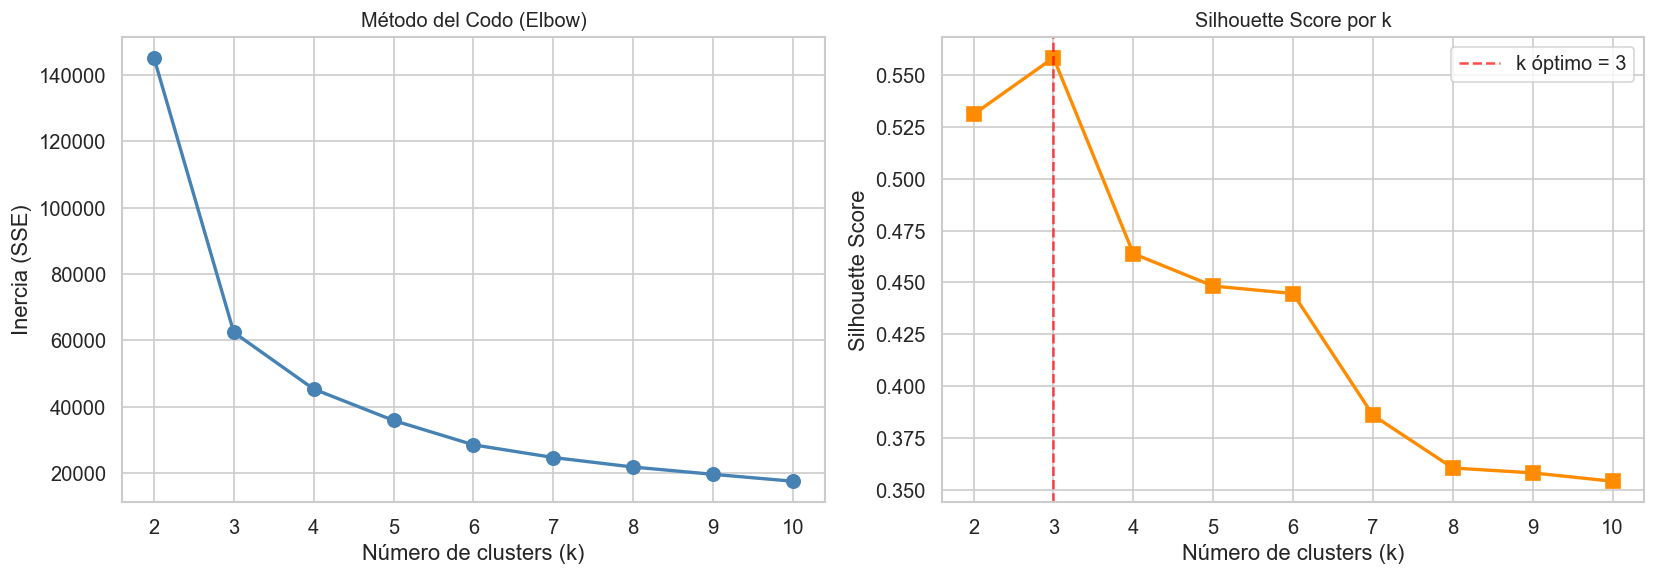

k sugerido por Silhouette Score: 3


In [13]:
# Visualización Elbow + Silhouette
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
axes[0].plot(list(K_RANGE), inertias, 'o-', color='steelblue', linewidth=2, markersize=8)
axes[0].set_title('Método del Codo (Elbow)', fontsize=12)
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('Inercia (SSE)')
axes[0].set_xticks(list(K_RANGE))

# Silhouette
axes[1].plot(list(K_RANGE), silhouettes, 's-', color='darkorange', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score por k', fontsize=12)
axes[1].set_xlabel('Número de clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(K_RANGE))

k_opt = list(K_RANGE)[np.argmax(silhouettes)]
axes[1].axvline(x=k_opt, color='red', linestyle='--', alpha=0.7, label=f'k óptimo = {k_opt}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'k sugerido por Silhouette Score: {k_opt}')

## 9. K-Means final

In [14]:
# Ajustar k según análisis previo (modificar si es necesario)
K_FINAL = k_opt

kmeans = KMeans(n_clusters=K_FINAL, random_state=SEED, n_init=10)
clusters = kmeans.fit_predict(X_pca)

# Agregar cluster al dataframe original
df['Cluster'] = clusters

print(f'K-Means ejecutado con k={K_FINAL}')
print(f'Silhouette Score final: {silhouette_score(X_pca, clusters):.4f}')
print()
print('Distribución de clusters:')
print(df['Cluster'].value_counts().sort_index())

K-Means ejecutado con k=3
Silhouette Score final: 0.5582

Distribución de clusters:
Cluster
0     9598
1    18276
2     7126
Name: count, dtype: int64


## 10. Visualización de clusters en espacio PCA

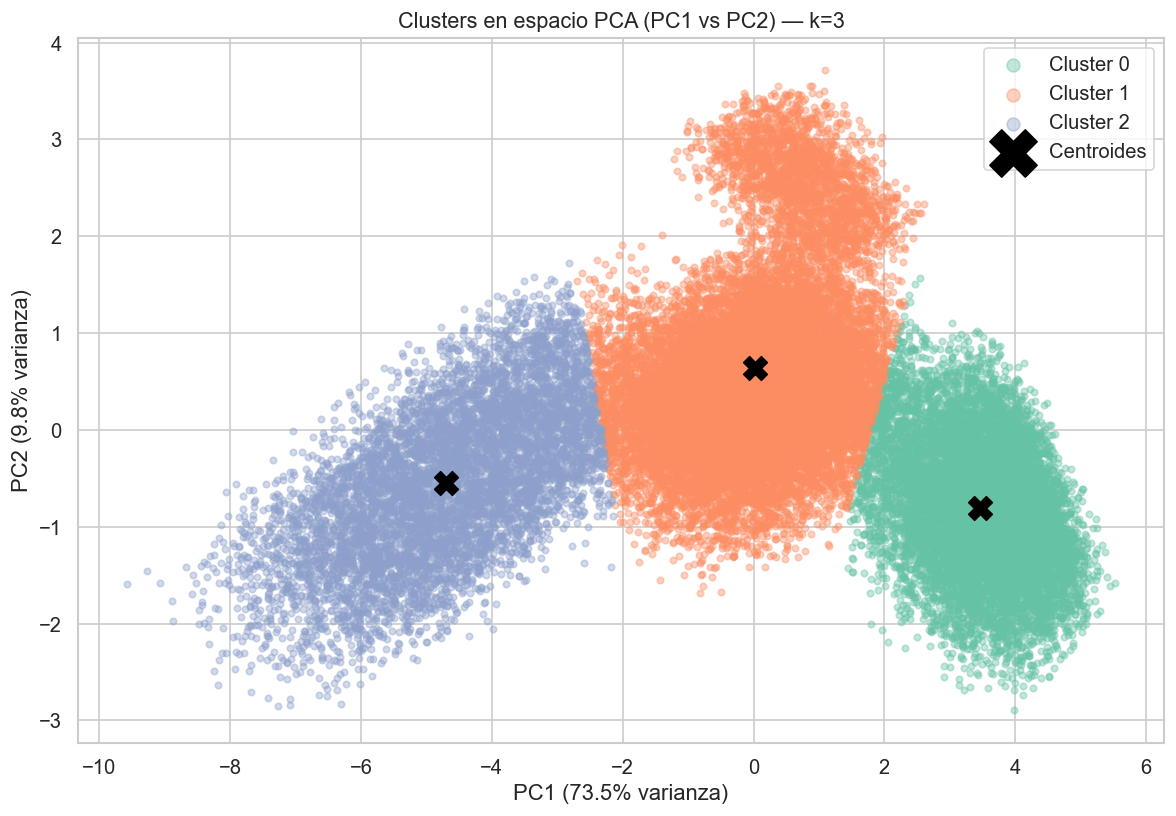

In [15]:
# Scatter plot PC1 vs PC2 coloreado por cluster
fig, ax = plt.subplots(figsize=(10, 7))

palette = sns.color_palette('Set2', K_FINAL)

for c in range(K_FINAL):
    mask = clusters == c
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        label=f'Cluster {c}',
        alpha=0.4, s=15,
        color=palette[c]
    )

# Centroides
centroids_2d = kmeans.cluster_centers_[:, :2]
ax.scatter(
    centroids_2d[:, 0], centroids_2d[:, 1],
    c='black', marker='X', s=200, zorder=5, label='Centroides'
)

ax.set_title(f'Clusters en espacio PCA (PC1 vs PC2) — k={K_FINAL}', fontsize=13)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)')
ax.legend(markerscale=2)
plt.tight_layout()
plt.show()

## 11. Análisis Silhouette por muestra

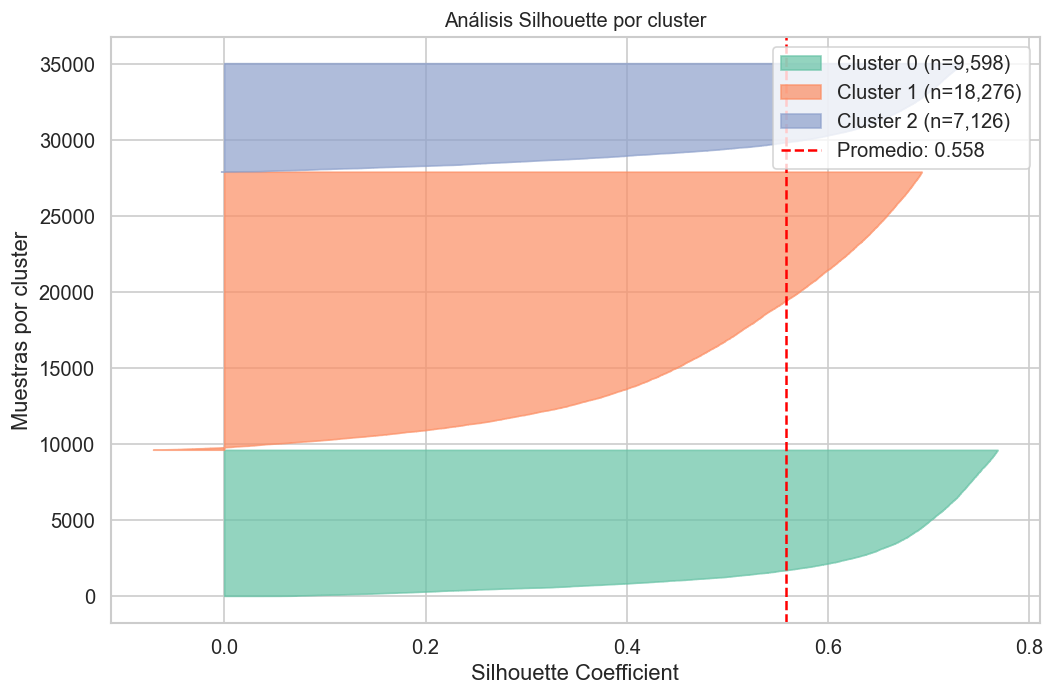

In [16]:
# Silhouette plot por cluster
silhouette_vals = silhouette_samples(X_pca, clusters)

fig, ax = plt.subplots(figsize=(9, 6))
palette = sns.color_palette('Set2', K_FINAL)
y_lower = 10

for c in range(K_FINAL):
    c_silhouette = np.sort(silhouette_vals[clusters == c])
    size = len(c_silhouette)
    y_upper = y_lower + size
    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0, c_silhouette,
        alpha=0.7, color=palette[c], label=f'Cluster {c} (n={size:,})'
    )
    y_lower = y_upper + 10

avg_score = silhouette_score(X_pca, clusters)
ax.axvline(x=avg_score, color='red', linestyle='--', label=f'Promedio: {avg_score:.3f}')
ax.set_title('Análisis Silhouette por cluster', fontsize=12)
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Muestras por cluster')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 12. Perfilado estadístico de clusters

¿Qué caracteriza a cada cluster? Comparamos las medias de cada variable original por cluster.

In [17]:
# Medias por cluster
perfil = df.groupby('Cluster')[FEATURES].mean().round(2)
print('=== PERFIL ESTADÍSTICO POR CLUSTER ===')
print(perfil.T.to_string())

=== PERFIL ESTADÍSTICO POR CLUSTER ===
Cluster                            0        1         2
AQI                            38.35   129.66    269.86
PM2.5                          21.02    71.11    148.80
PM10                           34.44   116.53    243.37
Deforestation_Rate_%            0.64     2.79      3.79
Afforestation_Rate_%            3.09     1.47      0.81
Vehicles_Increase_%             4.09     8.66     17.70
Industries_Increase_%           2.85     6.15     12.17
Env_Budget_Million_USD        729.14   201.40    105.82
Population_Density_Per_SqKm  6179.00  7300.64  18222.28
CO2_Emissions_MT              103.54   175.53    330.05
Green_Space_Ratio_%            42.44    34.33     20.41
Avg_Life_Expectancy_Index      83.90    76.76     67.22


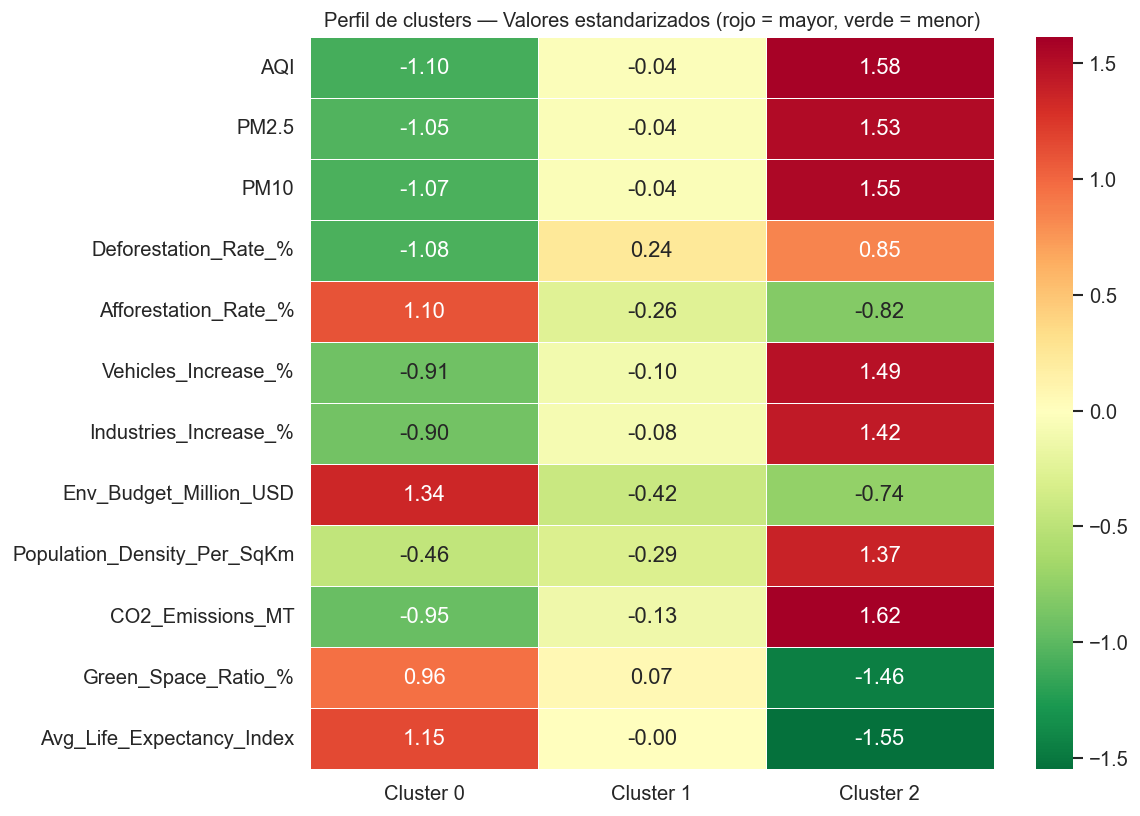

In [18]:
# Heatmap de perfiles — valores estandarizados para comparabilidad
perfil_scaled = pd.DataFrame(
    scaler.transform(perfil),
    index=perfil.index,
    columns=FEATURES
).T
perfil_scaled.columns = [f'Cluster {c}' for c in perfil_scaled.columns]

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(
    perfil_scaled,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn_r',
    center=0,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Perfil de clusters — Valores estandarizados (rojo = mayor, verde = menor)', fontsize=12)
plt.tight_layout()
plt.show()

In [19]:
# Distribución geográfica por cluster (Top países por cluster)
print('=== PAÍSES MÁS FRECUENTES POR CLUSTER ===')
for c in range(K_FINAL):
    top_paises = df[df['Cluster'] == c]['Country'].value_counts().head(5)
    print(f'\nCluster {c} (n={len(df[df["Cluster"]==c]):,}):')
    print(top_paises.to_string())

=== PAÍSES MÁS FRECUENTES POR CLUSTER ===

Cluster 0 (n=9,598):
Country
Spain        802
Sweden       800
Australia    795
Canada       784
Japan        777

Cluster 1 (n=18,276):
Country
Russia          824
Ethiopia        798
Indonesia       796
Peru            795
South Africa    792

Cluster 2 (n=7,126):
Country
Egypt         724
Iran          723
Pakistan      722
Bangladesh    713
Myanmar       709


C:\Users\Hin-j\AppData\Local\Temp\ipykernel_13024\1184985358.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Hin-j\AppData\Local\Temp\ipykernel_13024\1184985358.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Hin-j\AppData\Local\Temp\ipykernel_13024\1184985358.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Hin-j\AppData\Local\Temp\ipykernel_13024\1184985358.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` 

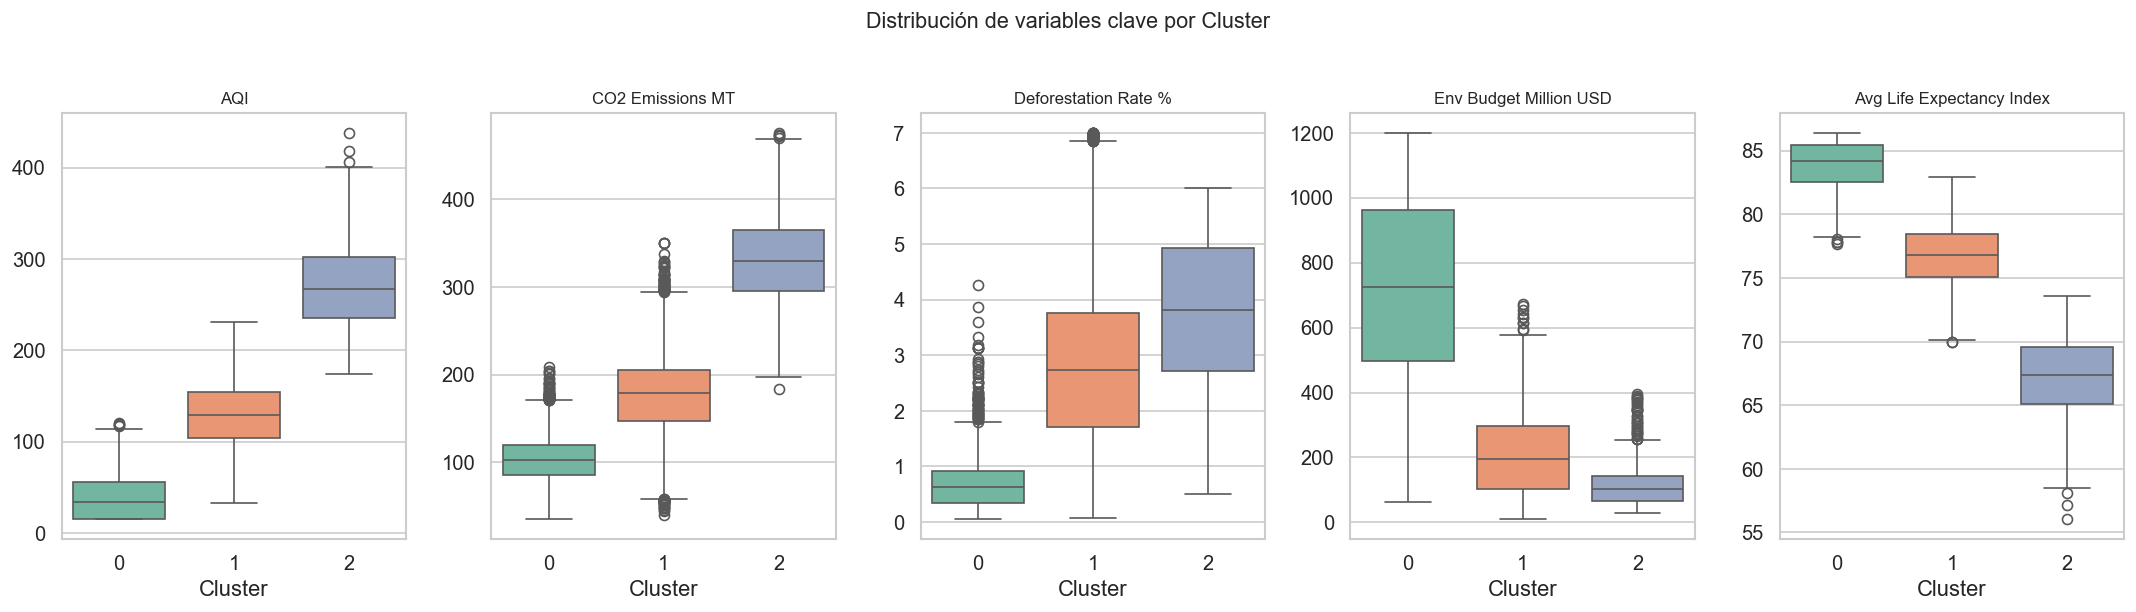

In [20]:
# Boxplots de variables clave por cluster
KEY_VARS = ['AQI', 'CO2_Emissions_MT', 'Deforestation_Rate_%', 
            'Env_Budget_Million_USD', 'Avg_Life_Expectancy_Index']

fig, axes = plt.subplots(1, len(KEY_VARS), figsize=(18, 5))

for i, var in enumerate(KEY_VARS):
    sns.boxplot(
        data=df, x='Cluster', y=var,
        palette='Set2', ax=axes[i]
    )
    axes[i].set_title(var.replace('_', ' '), fontsize=10)
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel('')

plt.suptitle('Distribución de variables clave por Cluster', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 13. Evolución temporal de clusters (2014–2023)

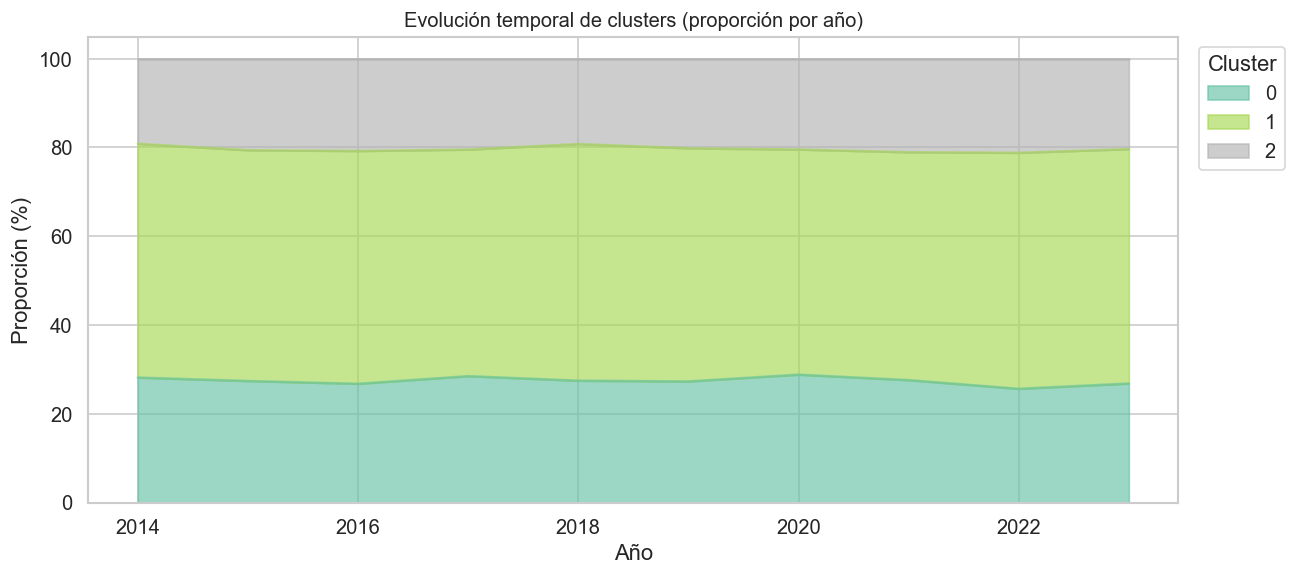

In [21]:
# Proporción de registros por cluster a lo largo del tiempo
evol = df.groupby(['Year', 'Cluster']).size().unstack(fill_value=0)
evol_pct = evol.div(evol.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 5))
evol_pct.plot(kind='area', alpha=0.65, colormap='Set2', ax=ax)
ax.set_title('Evolución temporal de clusters (proporción por año)', fontsize=12)
ax.set_xlabel('Año')
ax.set_ylabel('Proporción (%)')
ax.legend(title='Cluster', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 14. Resumen ejecutivo

Completa esta sección con la interpretación de cada cluster tras revisar el heatmap de perfiles y los boxplots.

In [22]:
print('=== RESUMEN DEL ANÁLISIS ===')
print(f'Variables analizadas:    {len(FEATURES)}')
print(f'Componentes PCA:         {N_COMPONENTS}')
print(f'Varianza explicada PCA:  {pca.explained_variance_ratio_.sum()*100:.2f}%')
print(f'Clusters encontrados:    {K_FINAL}')
print(f'Silhouette Score:        {silhouette_score(X_pca, clusters):.4f}')
print(f'Total de registros:      {len(df):,}')
print()
print('Distribución final de clusters:')
print(df['Cluster'].value_counts().sort_index().to_string())
print()
print('--- Interpretación de clusters (completar tras análisis visual) ---')
for c in range(K_FINAL):
    print(f'Cluster {c}: [Nombre descriptivo pendiente — e.g. "Alta contaminación / Baja inversión"]')

=== RESUMEN DEL ANÁLISIS ===
Variables analizadas:    12
Componentes PCA:         2
Varianza explicada PCA:  83.36%
Clusters encontrados:    3
Silhouette Score:        0.5582
Total de registros:      35,000

Distribución final de clusters:
Cluster
0     9598
1    18276
2     7126

--- Interpretación de clusters (completar tras análisis visual) ---
Cluster 0: [Nombre descriptivo pendiente — e.g. "Alta contaminación / Baja inversión"]
Cluster 1: [Nombre descriptivo pendiente — e.g. "Alta contaminación / Baja inversión"]
Cluster 2: [Nombre descriptivo pendiente — e.g. "Alta contaminación / Baja inversión"]
